In [1]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import WhitespaceTokenizer
from nltk import pos_tag
from nltk.corpus import wordnet
import nltk

nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

### Sources:

*   [GloVe Embedding article](https://medium.com/analytics-vidhya/basics-of-using-pre-trained-glove-vectors-in-python-d38905f356db)
*    [Emojis - source1](https://towardsdatascience.com/emojis-aid-social-media-sentiment-analysis-stop-cleaning-them-out-bb32a1e5fc8e)
*   [Emojis - source2](https://medium.com/@HeCanThink/emoji-lets-deal-with-in-python-dcc88b1f8ab1)
*   [Emojis - source3](https://kt.ijs.si/data/Emoji_sentiment_ranking/)
*   [Spell checker - source 1](https://www.johnsnowlabs.com/easily-correcting-typos-and-spelling-errors-on-texts-with-spark-nlp-and-python/)
*   [Spell checker - source 2](https://stackoverflow.com/questions/69851442/q-python-spell-checker-using-nltk)
*   [Lemmatization with a pretrained model - Spark NLP](https://sparknlp.org/2021/11/22/lemma_antbnc_en.html)

In [2]:
import pandas as pd
import gensim
import emoji
import nltk
import torch
import sys
import shutil
import urllib
import tarfile
from pathlib import Path
import numpy as np
from typing import Iterable
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import gensim.downloader as gloader
from gensim.models import KeyedVectors
from autocorrect import Speller
import os
import simplejson as sj

import pandas as pd
from typing import List, Callable, Dict
from collections import OrderedDict
import umap

import re

from sklearn.metrics.pairwise import cosine_similarity


## hashtags segmenter: https://github.com/grantjenks/python-wordsegment
import wordsegment as ws 
ws.load()

## mention and lemmatization
import spacy
nlp = spacy.load("en_core_web_sm")

LEMMATIZED_TRAIN_DATA_FILE = "training_data_lemm.csv"
LEMMATIZED_VALIDATION_DATA_FILE = "validation_data_lemm.csv"
LEMMATIZED_TEST_DATA_FILE = "test_data_lemm.csv"

In [3]:
# choose right device
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print('Torch Device: %s' % device)

Torch Device: mps


# Data Visualization
Download data, Load Json in Pandas dataframes, Generate Hard Labels, Filter English, Filter columns, Encode Hard Label in 0-1

# Data Cleaning

In [4]:
## REGEXs
GOOD_SYMBOLS_RE = re.compile('[^0-9a-z +_<>]')
HASHTAG_REGEX = re.compile('#\w+')
MENTION_REGEX = re.compile("@\w+")
URL_REGEX = re.compile('https?://(?:www\.)?[\w-]+\.[\w/._-]+')
## SPECIAL TOKENs
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_GREATER_THAN = " <GREATER_THAN> "
TOKEN_LEFT_SINGLE_QUOTE = " <LEFT_SINGLE_QUOTE> "
TOKEN_RIGHT_SINGLE_QUOTE = " <RIGHT_SINGLE_QUOTE> "
TOKEN_LEFT_DOUBLE_QUOTE = " <LEFT_DOUBLE_QUOTE> "
TOKEN_RIGHT_DOUBLE_QUOTE = " <RIGHT_DOUBLE_QUOTE> "
TOKEN_ELLIPSIS = " <ELLIPSIS> "
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_URL = " <URL> "
TOKEN_HASHTAG_START = " <HASHTAG_START> "
TOKEN_HASHTAG_END = " <HASHTAG_END> "

try:
    STOPWORDS = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    STOPWORDS = set(stopwords.words('english'))

In [5]:
def lower(text):
    return text.lower()

def strip_text(text):
    return text.strip()

def contains_emoji(text):
    return any(emoji.is_emoji(char) for char in text)

def contains_mention(text):
    return re.findall(MENTION_REGEX, text)

def replace_urls_with_token(text):
    return re.sub(URL_REGEX, TOKEN_URL, text)

def remove_angle_brackets(text):
    text.replace("&amp", " and ")
    text.replace("<", TOKEN_LESSER_THAN)
    text.replace(">", TOKEN_GREATER_THAN)
    return text

def emoji2description(text):
    return emoji.replace_emoji(text, replace=lambda chars, data_dict: ' '.join(data_dict['en'].split('_')).strip(':')+' ')

def encode_data_with_function(data, encoding, column = 'tweet'):
    data[column] = data[column].apply(encoding)
    return data

def replace_quote_symbols(text):
    text = text.replace("‘", TOKEN_LEFT_SINGLE_QUOTE)
    text = text.replace("’", TOKEN_RIGHT_SINGLE_QUOTE)
    text = text.replace("“", TOKEN_LEFT_DOUBLE_QUOTE)
    text = text.replace("”", TOKEN_RIGHT_DOUBLE_QUOTE)
    text = text.replace("\"", TOKEN_LEFT_DOUBLE_QUOTE)
    text = text.replace("\"", TOKEN_RIGHT_DOUBLE_QUOTE)
    text = text.replace("...", TOKEN_ELLIPSIS)
    return text

def replace_mention(text):
    mention = re.findall(MENTION_REGEX, text)
    if mention:
        new_sen = text
        for m in mention:
            doc = nlp(m)
            sub = [c.label_ for c in doc.ents]
            if sub:
                new_sen = new_sen.replace(m, f" <{sub[0]}> ")
            else:
                new_sen = new_sen.replace(m, f" <{[c.pos_ for c in doc][0]}> ")
        return new_sen
    else:
        return text    
    
def replace_hashtag(text):
    """
    Replaces hashtags, by segmenting hashtags and adding special tokens in front and at the end of it.
    """
    def segment(x) :
        return TOKEN_HASHTAG_START+' '.join(ws.segment(x))+TOKEN_HASHTAG_END
    return re.sub(HASHTAG_REGEX, lambda x: segment(x.group(0)), text)


# def replace_special_characters(text: str) -> str:
#     """
#     Replaces special characters, such as paranthesis, with spacing character
#     """
#     return REPLACE_BY_SPACE_RE.sub(' ', text)

def replace_br(text: str) -> str:
    """
    Replaces br characters
    """
    return text.replace('br', '')

def filter_out_unwanted_symbols(text: str) -> str:
    """
    Removes any special character that is not in the good symbols list (check regular expression)
    """
    return GOOD_SYMBOLS_RE.sub(' ', text)

def remove_stopwords(text: str) -> str:
    return ' '.join([x for x in text.split() if x and x not in STOPWORDS])

def strip_text(text: str) -> str:
    """
    Removes any left or right spacing (including carriage return) from text.
    """
    return text.strip()

In [6]:
def majority_vote(lst):
    count = Counter(lst)
    return 1 if count.most_common(1)[0][0] == "YES" else 0

def yes_probability(lst):
    # Count the number of YES and NO votes
    yes_count = lst.count("YES")
    no_count = lst.count("NO")

    # Calculate the probability of YES
    total = yes_count + no_count
    if total == 0:
        return None  # To handle cases where there are no "YES" or "NO" votes in the list
    else:
        return yes_count / total

def generate_labels_task1(data):
    data = data.drop(['annotators','number_annotators','gender_annotators','age_annotators','labels_task2','labels_task3'],axis=1)
    data['hard_label_task1'] = data['labels_task1'].apply(majority_vote)
    data['soft_label_task1'] = data['labels_task1'].apply(yes_probability)
    return data

# def load_and_preprocess_dataset(file_path):
#     data = pd.read_json(file_path).T
#     data = generate_labels_task1(data)
#     data['original'] = data['tweet'] #to remove
#     columns_to_keep = ['id_EXIST','lang','tweet', 'hard_label_task1','soft_label_task1', 'original']
#     data = data[columns_to_keep]
#     data = filter_english_only(data)
#     data = encode_data_with_function(data,remove_angle_brackets)
#     data = encode_data_with_function(data,emoji2description)
#     data = encode_data_with_function(data,replace_mention)
#     data = encode_data_with_function(data,replace_hashtag)
#     data = encode_data_with_function(data,replace_urls_with_token)
#     data = encode_data_with_function(data,replace_quote_symbols)
#     # data = encode_data_with_function(data,replace_special_characters)
#     data = encode_data_with_function(data,filter_out_unwanted_symbols)
#     #data = encode_data_with_function(data,replace_br)
#     data = encode_data_with_function(data,remove_stopwords)
#     data = encode_data_with_function(data,lower)
#     data = encode_data_with_function(data,strip_text)
#     return data

def load_dataset(file_path):
  return pd.read_json(file_path).T

def load_and_preprocess_dataset_new(file_path, verbose = True, index_to_print=1):
    # Load and transpose the data
    data = pd.read_json(file_path).T
    if verbose:
      print(f"Initial Data (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Generate labels for task 1
    data = generate_labels_task1(data)
    if verbose:
      print(f"After generate_labels_task1 (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Add 'original' column (to remove)
    data['original'] = data['tweet']

    # Keep only necessary columns
    columns_to_keep = ['id_EXIST', 'lang', 'tweet', 'hard_label_task1', 'soft_label_task1', 'original']
    data = data[columns_to_keep]
    if verbose:
      print(f"After keeping specific columns (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Filter for English-only data
    data = filter_english_only(data)
    if verbose:
      print(f"After filter_english_only (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Apply each encoding function and print the result
    encoding_functions = [
        remove_angle_brackets,
        emoji2description,
        replace_mention,
        replace_hashtag,
        replace_urls_with_token,
        replace_quote_symbols,
        # replace_special_characters,
        lower,
        filter_out_unwanted_symbols,
        remove_stopwords,
        strip_text
    ]

    for func in encoding_functions:
        data = encode_data_with_function(data, func)
        if verbose:
          print(f"After {func.__name__} (index == {index_to_print}):\n", data.loc[index_to_print]['tweet'] if index_to_print in data.index else "Index not found")

    return data


def filter_english_only(df):
    new_df = df[df['lang'].astype('str').str.contains('en')]
    return new_df


In [7]:
#Debug purpose
load_and_preprocess_dataset_new("data/training.json", verbose=True, index_to_print=202722)

Initial Data (index == 202722):
 id_EXIST                                                        202722
lang                                                                en
tweet                Today’s women are not the same as women were i...
number_annotators                                                    6
annotators           [Annotator_720, Annotator_721, Annotator_722, ...
gender_annotators                                   [F, F, M, M, M, F]
age_annotators                  [18-22, 23-45, 18-22, 23-45, 46+, 46+]
labels_task1                              [YES, NO, NO, YES, YES, YES]
labels_task2               [JUDGEMENTAL, -, -, DIRECT, DIRECT, DIRECT]
labels_task3         [[IDEOLOGICAL-INEQUALITY], [-], [-], [STEREOTY...
split                                                         TRAIN_EN
Name: 202722, dtype: object
After generate_labels_task1 (index == 202722):
 id_EXIST                                                       202722
lang                                    

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
200001,200001,en,ffs laying blame bastard murdered novel idea k...,1,0.500000,FFS! How about laying the blame on the bastard...
200002,200002,en,writing uni essay local pub coffee random old ...,1,0.833333,Writing a uni essay in my local pub with a cof...
200003,200003,en,<noun> 2021 1921 dont appreciate two rides tea...,1,0.666667,@UniversalORL it is 2021 not 1921. I dont appr...
200004,200004,en,<org> unacceptable use title men interviewed f...,1,0.500000,@GMB this is unacceptable. Use her title as yo...
200005,200005,en,<left_single_quote> making harder target <righ...,1,0.500000,‘Making yourself a harder target’ basically bo...
...,...,...,...,...,...,...
203256,203256,en,idk <right_single_quote> bitches think half as...,1,1.000000,idk why y’all bitches think having half your a...
203257,203257,en,part experiment <org> learning though little b...,1,1.000000,This has been a part of an experiment with @Wo...
203258,203258,en,<left_double_quote> take already <left_double_...,1,0.666667,"""Take me already"" ""Not yet. You gotta be ready..."
203259,203259,en,<person> look like whore lh <url>,1,1.000000,@clintneedcoffee why do you look like a whore?...


In [8]:
processed_training_data = load_and_preprocess_dataset_new("data/training.json", verbose=False)
print('Finished training')
processed_validation_data = load_and_preprocess_dataset_new("data/validation.json", verbose=False)
print('Finished validation')
processed_test_data = load_and_preprocess_dataset_new("data/test.json", verbose=False)
print('Finished test')

Finished training
Finished validation
Finished test


In [9]:
print(processed_training_data.shape)
print(processed_validation_data.shape)
print(processed_test_data.shape)

print(processed_training_data.columns)


(3260, 6)
(177, 6)
(312, 6)
Index(['id_EXIST', 'lang', 'tweet', 'hard_label_task1', 'soft_label_task1',
       'original'],
      dtype='object')


In [10]:
display(processed_training_data.head())

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
200001,200001,en,ffs laying blame bastard murdered novel idea k...,1,0.500000,FFS! How about laying the blame on the bastard...
200002,200002,en,writing uni essay local pub coffee random old ...,1,0.833333,Writing a uni essay in my local pub with a cof...
200003,200003,en,<noun> 2021 1921 dont appreciate two rides tea...,1,0.666667,@UniversalORL it is 2021 not 1921. I dont appr...
200004,200004,en,<org> unacceptable use title men interviewed f...,1,0.500000,@GMB this is unacceptable. Use her title as yo...
200005,200005,en,<left_single_quote> making harder target <righ...,1,0.500000,‘Making yourself a harder target’ basically bo...


In [11]:
target = "hard_label_task1"

In [12]:
processed_training_data[target].value_counts()

hard_label_task1
0    1941
1    1319
Name: count, dtype: int64

Train '0:1' score ratio --> 1.47 : 1
Test  '0:1' score ratio --> 1.21 : 1


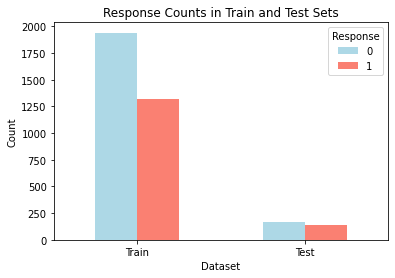

In [13]:
train_counts = processed_training_data[target].value_counts()
test_counts = processed_test_data[target].value_counts()

# Combine counts into a single DataFrame for plotting
counts_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
}).T  # Transpose to have "yes" and "no" as columns

train_neg_over_pos = counts_df[0]['Train']/counts_df[1]['Train']
test_neg_over_pos = counts_df[0]['Test']/counts_df[1]['Test']
print(f"Train '0:1' score ratio --> {train_neg_over_pos:.2f} : 1")
print(f"Test  '0:1' score ratio --> {test_neg_over_pos:.2f} : 1")

# Plotting
counts_df.plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Response Counts in Train and Test Sets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.show()

## Lemmatization - Same as Tutorial 1

In [14]:
def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:          
        return 'n'

def lem_text(text, lemmatizer = WordNetLemmatizer(), tokenizer = WhitespaceTokenizer(), spell_checker=True, spell=Speller(lang='en')):
    _text = []
    # segment all words that does not contain a '<' inside
    for t in text.split(" "):
        _text += [t if "<" in t else ' '.join(ws.segment(t))]
    text = ' '.join(_text)

    # check for mis-spelling of words
    tokens = tokenizer.tokenize(text)
    if spell_checker:
      tokens = [spell(w) for w in tokens]
    # lemmatize words by their semantics
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag)) for word, tag in tagged]
    return " ".join(words)

In [15]:
def load_lemmatized_data(preprocessed_data, lem_fn=lem_text , path=""):
    if not os.path.isfile(path):
        lem_data = encode_data_with_function(preprocessed_data,lem_fn)
        lem_data.to_csv(path)
        return lem_data
    else:
        return pd.read_csv(path)

In [16]:
# load lemmatized training data
print("Lemmatizing training data.")
lem_training_data = load_lemmatized_data(processed_training_data, path=LEMMATIZED_TRAIN_DATA_FILE)
# load lemmatized validation data
print("Lemmatizing validation data.")
lem_validation_data = load_lemmatized_data(processed_validation_data, path=LEMMATIZED_VALIDATION_DATA_FILE)
# load lemmatized test data
print("Lemmatizing test data.")
lem_test_data = load_lemmatized_data(processed_test_data, path=LEMMATIZED_TEST_DATA_FILE)

Lemmatizing training data.
Lemmatizing validation data.
Lemmatizing test data.


# Task 3 - Text encoding

In [17]:
EMB_DIM = 50

In [18]:
def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider

    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    # https://github.com/piskvorky/gensim-data?tab=readme-ov-file#datasets
    if model_type.strip().lower() == 'word2vec':
        download_path = "word2vec-google-news-300"
    elif model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'glove-twitter':
        download_path = "glove-twitter-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")
        
    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print("Glove-twitter: 25, 50, 100, 200")
        print('FastText: 300')
        raise e

    return emb_model

In [19]:
embedding_model = load_embedding_model(model_type="glove-twitter",
                                       embedding_dimension=EMB_DIM)

In [20]:
df_embed = pd.DataFrame(data=embedding_model.vectors)
df_embed.describe()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
count,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,...,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06
mean,-2.189694e-01,1.726908e-01,-5.617134e-02,6.307274e-02,9.606626e-03,-2.346111e-01,-1.673192e-01,-2.561416e-01,1.299083e-01,-3.417983e-01,...,8.865857e-01,-1.498127e-02,1.021143e-01,-1.295955e-01,-3.283582e-01,1.301438e-01,-2.061018e-02,5.735761e-02,1.400820e-01,2.258864e-01
std,6.761081e-01,6.944407e-01,6.916828e-01,6.787786e-01,6.724812e-01,6.458723e-01,6.574651e-01,6.568925e-01,6.580209e-01,6.958572e-01,...,6.979791e-01,7.033525e-01,6.897094e-01,6.691399e-01,6.530790e-01,6.655709e-01,6.396263e-01,6.755373e-01,6.775005e-01,7.008290e-01
min,-6.841300e+00,-5.047700e+00,-5.438000e+00,-5.890500e+00,-5.565400e+00,-5.154800e+00,-4.560500e+00,-6.026900e+00,-6.973900e+00,-5.919400e+00,...,-5.068500e+00,-6.539600e+00,-4.826100e+00,-5.101300e+00,-6.305100e+00,-5.560800e+00,-6.061000e+00,-4.887500e+00,-5.418700e+00,-5.085200e+00
25%,-6.413400e-01,-2.436100e-01,-4.679675e-01,-3.681900e-01,-4.101000e-01,-6.339200e-01,-5.818400e-01,-6.666175e-01,-2.842500e-01,-7.918400e-01,...,4.949600e-01,-4.598200e-01,-3.346475e-01,-5.460300e-01,-7.529800e-01,-2.694100e-01,-4.273100e-01,-3.651200e-01,-2.839800e-01,-2.194600e-01
50%,-2.189900e-01,2.007850e-01,-4.527100e-02,5.317900e-02,4.772650e-03,-2.469000e-01,-1.770900e-01,-2.591700e-01,1.371100e-01,-3.565800e-01,...,9.351600e-01,-2.827900e-02,1.090500e-01,-1.173900e-01,-3.416500e-01,1.419800e-01,-2.246000e-02,6.179700e-02,1.519800e-01,2.088050e-01
75%,2.080900e-01,6.189800e-01,3.714400e-01,4.816900e-01,4.271400e-01,1.549200e-01,2.374700e-01,1.492100e-01,5.490300e-01,9.211150e-02,...,1.337700e+00,4.182375e-01,5.358700e-01,3.018000e-01,8.437975e-02,5.460100e-01,3.849000e-01,4.888800e-01,5.653500e-01,6.511900e-01
max,5.123200e+00,5.519100e+00,5.251400e+00,6.513400e+00,6.321600e+00,5.412600e+00,4.639100e+00,5.666800e+00,5.547700e+00,4.933300e+00,...,5.409900e+00,5.424700e+00,5.582800e+00,5.098700e+00,5.321000e+00,4.581900e+00,4.588900e+00,4.855900e+00,5.119900e+00,5.938800e+00


In [21]:
def build_vocabulary(df: pd.DataFrame, add_glove_tokens = False, model = None, additional_tokens = None) -> (Dict[int, str], Dict[str, int], List[str]):
    """
    Builds a vocabulary that is the union of tokens from the dataset and model embeddings.

    :param df: pandas DataFrame containing the dataset (column 'tweet' with sentences).
    :param model: Model object containing pre-trained embeddings.
    :return:
      - idx_to_word: Dictionary mapping vocabulary index to word.
      - word_to_idx: Dictionary mapping word to vocabulary index.
      - word_listing: List of unique terms in the vocabulary.
    """
    idx_to_word = OrderedDict()
    word_to_idx = OrderedDict()
    
    # Add tokens from training set
    curr_idx = 0
    for sentence in tqdm(df['tweet'].values, desc="Building vocabulary from dataset"):
        tokens = sentence.split()
        for token in tokens:
            if token not in word_to_idx:
                word_to_idx[token] = curr_idx
                idx_to_word[curr_idx] = token
                curr_idx += 1
    
    # Add tokens from GloVe (via Gensim)
    if add_glove_tokens:
      for token in tqdm(model.key_to_index, desc="Adding GloVe tokens"):
          if token not in word_to_idx:
              word_to_idx[token] = curr_idx
              idx_to_word[curr_idx] = token
              curr_idx += 1

    # Add additional special tokens
    if additional_tokens is not None and isinstance(additional_tokens, List):
        for token in additional_tokens:
            word_to_idx[token] = curr_idx
            idx_to_word[curr_idx] = token
            curr_idx += 1
        
    word_listing = list(idx_to_word.values())
    return idx_to_word, word_to_idx, word_listing

def evaluate_vocabulary(idx_to_word: Dict[int, str], word_to_idx: Dict[str, int],
                        word_listing: List[str], df: pd.DataFrame, check_default_size: bool = False):
    print("[Vocabulary Evaluation] Size checking...")
    assert len(idx_to_word) == len(word_to_idx)
    assert len(idx_to_word) == len(word_listing)

    print("[Vocabulary Evaluation] Content checking...")
    for i in tqdm(range(0, len(idx_to_word))):
        assert idx_to_word[i] in word_to_idx
        assert word_to_idx[idx_to_word[i]] == i

    print("[Vocabulary Evaluation] Consistency checking...")
    _, _, first_word_listing = build_vocabulary(df)
    _, _, second_word_listing = build_vocabulary(df)
    assert first_word_listing == second_word_listing

    print("[Vocabulary Evaluation] Toy example checking...")
    toy_df = pd.DataFrame.from_dict({
        'tweet': ["all that glitters is not gold", "all in all i like this assignment"]
    })
    _, _, toy_word_listing = build_vocabulary(toy_df)
    toy_valid_vocabulary = set(' '.join(toy_df['tweet'].values).split())
    assert set(toy_word_listing) == toy_valid_vocabulary

def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    word_listing):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.key_to_index.keys())
    oov = set(word_listing).difference(embedding_vocabulary)
    return list(oov)

Add Padding Token to vocabulary

In [22]:
PADDING_TOKEN="<pad>"
UNKNOWN_TOKEN="<unk>"

Create an initial vocab with words from training data (if add_glove_tokens = True add also GloVe precomputed tokens)

In [23]:
print("Building Training data Vocabulary.")
train_idx_to_word, train_word_to_idx, train_word_listing = build_vocabulary(lem_training_data,
add_glove_tokens = True, model = embedding_model, additional_tokens=[PADDING_TOKEN, UNKNOWN_TOKEN])
print(f'[Debug] Index -> Word vocabulary size: {len(train_idx_to_word)}')
print(f'[Debug] Word -> Index vocabulary size: {len(train_word_to_idx)}')
print(f'[Debug] Some words: {[(train_idx_to_word[idx], idx) for idx in np.arange(10) + 1]}')

Building Training data Vocabulary.


Adding GloVe tokens: 100%|███████| 1193514/1193514 [00:00<00:00, 2690663.47it/s]

[Debug] Index -> Word vocabulary size: 1194031
[Debug] Word -> Index vocabulary size: 1194031
[Debug] Some words: [('lay', 1), ('blame', 2), ('bastard', 3), ('murder', 4), ('novel', 5), ('idea', 6), ('know', 7), ('<url>', 8), ('write', 9), ('uni', 10)]


In [24]:
print("Vocabulary evaluation...")
evaluate_vocabulary(train_idx_to_word, train_word_to_idx, train_word_listing, lem_training_data)
print("Evaluation completed!")

Vocabulary evaluation...
[Vocabulary Evaluation] Size checking...
[Vocabulary Evaluation] Content checking...


100%|████████████████████████████| 1194031/1194031 [00:00<00:00, 3355350.47it/s]


[Vocabulary Evaluation] Consistency checking...


Building vocabulary from dataset: 100%|█| 3260/3260 [00:00<00:00, 461690.68it/s]


[Vocabulary Evaluation] Toy example checking...


Building vocabulary from dataset: 100%|████████| 2/2 [00:00<00:00, 61230.72it/s]

Evaluation completed!


Check OOV terms in training data.

In [25]:
train_oov_terms = check_OOV_terms(embedding_model, train_word_listing)
train_oov_percentage = float(len(train_oov_terms)) * 100 / len(train_word_listing)
print(f"Total OOV terms in training: {len(train_oov_terms)} ({train_oov_percentage:.2f}%)")
print(train_oov_terms)

Total OOV terms in training: 517 (0.04%)
['5', '2018', '500', '6', '<noun>', '238', '<part>', '2002', 'ambig', 'sissification', '73', '100horrormoviesin92', 'nonviable', '1980', '1988', 'ruggerio', '43', '1619', '81', 'deeded', '8m', '02', '2022', 'baryon', '56k', 'weightlift', '10km', 'p4ties', 'nonconforming', '18', 'sauropod', '2nd', '1987', '1930s', 'anupama', 'mechanization', '1st', '11th', '1866', 'carmelite', '90k', '180', '38', '14400', '51', '000s', 'keep1er', '<product>', '17m', 'actionaid', 'not8', 'prophetically', 'dishevel', '8', '1996', 'tudes', '00', 'volodymyr', 'fair1', 'p55x8wjgxk', '33', 'sensitization', '3d', '<hashtag_end>', '88', 'roofed', '333', 'racialized', 'arinanaxstyles420', '2005', '300', 'wh0r3s', 'votebluein2022', 'maccoby', '2000', 'anglicise', 'cinephiles', '2011', '<org>', 'shirtwaist', 'xx9srv1d', '498', '85', '9', 'radio3', '75', '80', 'bff22', 'gaisha', 'go2', '164', 'paternalistic', '59', '<gpe>', '2030s', '988', '<prop>', '5g', 'poet2021', 'postst

Save Vocabulary.

In [26]:
#Saving the vocabulary
vocab_path = Path.cwd().joinpath('data', 'vocab.json')

print(f"Saving vocabulary to {vocab_path}")
with vocab_path.open(mode='w') as f:
    sj.dump(train_word_to_idx, f, indent=4)
print("Saving completed!")

Saving vocabulary to /Users/utenteadmin/Desktop/UNIBO/2024-2025/1° semestre/Natural Language Processing/Assignment 1/NLP_AssignmentOne/data/vocab.json
Saving completed!


In [27]:
def find_closest_embedding(oov_word, embedding_model, embedding_dimension):
    """
    Finds the most similar word's embedding for the given OOV word.

    :param oov_word: OOV word (str)
    :param embedding_model: pre-trained word embedding model (gensim)
    :param embedding_dimension: dimensionality of the embeddings
    :return:
        - embedding vector of the most similar word
    """
    vocab_words = list(embedding_model.key_to_index.keys())
    vocab_vectors = np.array([embedding_model[word] for word in vocab_words])
    oov_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)  # Fallback vector

    # Compute similarity
    similarities = cosine_similarity([oov_vector], vocab_vectors).flatten()
    closest_idx = np.argmax(similarities)
    return vocab_vectors[closest_idx]

In [28]:
def build_embedding_matrix(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                           embedding_dimension: int,
                           word_to_idx: Dict[str, int],
                           vocab_size: int,
                           oov_terms: List[str],
                           dataset_type: str = 'train') -> np.ndarray:
    """
    Builds the embedding matrix of a specific dataset given a pre-trained word embedding model

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_to_idx: vocabulary map (word -> index) (dict)
    :param vocab_size: size of the vocabulary
    :param oov_terms: list of OOV terms (list)

    :return
        - embedding matrix that assigns a high dimensional vector to each word in the dataset specific vocabulary (shape |V| x d)
    """
    embedding_matrix = np.zeros((vocab_size, embedding_dimension), dtype=np.float32)
    for word, idx in tqdm(word_to_idx.items()):
        if dataset_type == 'train':
            try:
                embedding_vector = embedding_model[word]
            except KeyError:
                embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        elif dataset_type in ['validation', 'test']:
            if word in oov_terms:
                embedding_vector = find_closest_embedding(word, embedding_model, embedding_dimension)
            else:
                try:
                    embedding_vector = embedding_model[word]
                except KeyError:
                    embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)
        else:
            embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        embedding_matrix[idx] = embedding_vector
    return embedding_matrix

In [29]:
embedding_matrix = build_embedding_matrix(embedding_model, EMB_DIM, train_word_to_idx, len(train_word_to_idx), train_oov_terms)
embedding_model.add_vectors(train_word_listing, embedding_matrix)
print(f"Embedding matrix shape: {embedding_model.vectors.shape}")

100%|█████████████████████████████| 1194031/1194031 [00:02<00:00, 588901.35it/s]


Embedding matrix shape: (1194031, 50)


Manage OOV terms in validation and test data.

In [30]:
print("Building Validation Word listing.")
_, _, validation_word_listing = build_vocabulary(lem_validation_data, add_glove_tokens = False, model = embedding_model)
print("Building Test Word listing.")
_, _, test_word_listing = build_vocabulary(lem_test_data, add_glove_tokens = False, model = embedding_model)

Building Validation Word listing.


Building vocabulary from dataset: 100%|███| 177/177 [00:00<00:00, 168725.41it/s]


Building Test Word listing.


Building vocabulary from dataset: 100%|███| 312/312 [00:00<00:00, 106271.14it/s]


Find OOV of Test and Validation data w.r.t. to training data vocabulary.

In [31]:
validation_oov_terms = check_OOV_terms(embedding_model, validation_word_listing)
validation_oov_percentage = float(len(validation_oov_terms)) * 100 / len(validation_word_listing)
print(f"Total OOV terms in Validation Data: {len(validation_oov_terms)} ({validation_oov_percentage:.2f}%)")
print(validation_oov_terms)
test_oov_terms = check_OOV_terms(embedding_model, test_word_listing)
test_oov_percentage = float(len(test_oov_terms)) * 100 / len(test_word_listing)
print(f"Total OOV terms in Test Data: {len(test_oov_terms)} ({test_oov_percentage:.2f}%)")
print(test_oov_terms)

Total OOV terms in Validation Data: 19 (1.19%)
['kimjiyoungborn1982', '68', '20hr', 'hw3say', 'j5b9hs39w', '2any', 'curid', '55g', '114', 'ex7chan3g', '1986', 'jgemyxyogg', 'kiji', '175', '184m', 'ruqaiijah', 'canonize', 'gma23', 'nihilo']
Total OOV terms in Test Data: 25 (1.14%)
['debilitate', '1051', 'demonology', 'ns3m', 'overarch', 'mojassim80', '10off', 'peerage', '1950s', '14', 'cre8tiveconla', 'ramification', '8am', '031b0038', 'cre8tivecon', '80x', 'wknight', 'civilly', 'ieee', '100m', '40x', 'mearsheimer', '315', 'underlies', 'disembody']


Map OOV of Test and Validation data to UNKNOWN_TOKEN.

In [32]:
def replace_OOV_words(oov_words, unknown_token=UNKNOWN_TOKEN):
    return lambda text: " ".join([unknown_token if word in oov_words else word for word in text.split(" ")])

In [33]:
for word in validation_oov_terms:
    lem_validation_data_noOOV = encode_data_with_function(lem_validation_data, replace_OOV_words(validation_oov_terms))
for word in test_oov_terms:
    lem_test_data_noOOV = encode_data_with_function(lem_test_data, replace_OOV_words(test_oov_terms))

In [34]:
def visualize_embeddings(embeddings: np.ndarray,
                         word_annotations: List[str] = None,
                         word_to_idx: Dict[str, int] = None):
    """
    Plots given reduce word embeddings (2D). Users can highlight specific words (word_annotations list).

    :param embeddings: word embedding matrix of shape (words, 2) retrieved via a dimensionality reduction technique.
    :param word_annotations: list of words to be annotated.
    :param word_to_idx: vocabulary map (word -> index) (dict)
    """
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))

    if word_annotations:
        print(f"Annotating words: {word_annotations}")

        word_indexes = []
        for word in word_annotations:
            word_index = word_to_idx[word]
            word_indexes.append(word_index)

        word_indexes = np.array(word_indexes)

        other_embeddings = embeddings[np.setdiff1d(np.arange(embeddings.shape[0]), word_indexes)]
        target_embeddings = embeddings[word_indexes]

        ax.scatter(other_embeddings[:, 0], other_embeddings[:, 1], alpha=0.1, c='blue')
        ax.scatter(target_embeddings[:, 0], target_embeddings[:, 1], alpha=1.0, c='red')
        ax.scatter(target_embeddings[:, 0], target_embeddings[:, 1], alpha=1, facecolors='none', edgecolors='r', s=1000)

        for word, word_index in zip(word_annotations, word_indexes):
            word_x, word_y = embeddings[word_index, 0], embeddings[word_index, 1]
            ax.annotate(word, xy=(word_x, word_y))
    else:
        ax.scatter(embeddings[:, 0], embeddings[:, 1], alpha=0.1, c='blue')

    # We avoid outliers ruining the visualization if they are quite far away
    axis_x_limit = (np.min(embeddings[:, 0]), np.max(embeddings[:, 0]))
    axis_y_limit = (np.min(embeddings[:, 1]), np.max(embeddings[:, 1]))
    plt.xlim(left=axis_x_limit[0] - 0.5, right=axis_x_limit[1] + 0.5)
    plt.ylim(bottom=axis_y_limit[0] - 0.5, top=axis_y_limit[1] + 0.5)
    ax.set_xlim(axis_x_limit[0], axis_x_limit[1])
    ax.set_ylim(axis_y_limit[0], axis_y_limit[1])


def reduce_SVD(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies SVD dimensionality reduction.

    :param embeddings: word embedding matrix of shape (words, dim). In the case
                       of a word-word co-occurrence matrix the matrix shape would
                       be (words, words).

    :return
        - 2-dimensional word embedding matrix of shape (words, 2)
    """
    print("Running SVD reduction method...")
    svd = TruncatedSVD(n_components=2, n_iter=10)
    reduced = svd.fit_transform(embeddings)
    print("SVD reduction completed!")

    return reduced

def reduce_tSNE(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies t-SNE dimensionality reduction.
    """
    print("Running t-SNE reduction method... (it may take a while...)")
    tsne = TSNE(n_components=2, n_iter=1000, metric='cosine')
    reduced = tsne.fit_transform(embeddings)
    print("t-SNE reduction completed!")

    return reduced

def reduce_umap(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies UMAP dimensionality reduction.
    """
    print("Running UMAP reduction method... (it may take a while...)")
    umap_emb = umap.UMAP(n_components=2, metric='cosine')
    reduced = umap_emb.fit_transform(embeddings)
    print("UMAP reduction completed!")
    
    return reduced


# Feel free to play with word_annotations argument!
# Check the saved dictionary!
def run_visualization(method_name: str,
                      words_list: List[str],
                      word_to_idx: Dict[str, int],
                      co_occurrence_matrix):
    method_name = method_name.lower().strip()
    method_map = {
        'svd': reduce_SVD,
        'tsne': reduce_tSNE,
        'umap': reduce_umap
    }
    
    if method_name not in method_map:
        raise RuntimeError(f'Invalid method name! Got {method_name}.')
    
    reduced = method_map[method_name](co_occurrence_matrix)
    visualize_embeddings(reduced, words_list, word_to_idx)
    
# reduced_embedding_umap = reduce_umap(embedding_matrix)


In [35]:
# visualize_embeddings(reduced_embedding_umap, ['woman', 'man', 'stupid', '116', 'marco', 'whore'], initial_word_to_idx)

# plt.show()

# [Task 4] Model definition

In this task we tackle the Sexist classification problem by:
- Defining a PyTorch LSTM Model flexible enough to be integrated in custom training-loops
- Defining Training/Validation/Test PyTorch Datasets flexible enough to expose 'callback' functions
- Defining a HugginFace custom Training Loop to evaluate   
train a simple PyTorch LSTM Model on the Training dataset, evaluating it on the Evaluation dataset and testing it on the Test Set.

For this task 

Reproducibility Code.

In [36]:
import random
import numpy as np
import torch
import torch.nn as nn
from torchsummary import summary

def set_seed(seed=42):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.mps.manual_seed(seed)   
    torch.cuda.manual_seed(seed)               
    torch.cuda.manual_seed_all(seed)           
    torch.backends.cpu.deterministic = True 
    torch.backends.cudnn.deterministic = True 
    torch.backends.mps.deterministic = True 
set_seed()

## PyTorch LSTM model

Model definition:

In [37]:
class LSTM_Model(nn.Module):
    def __init__(self
                , vocab_dim
                , embed_dim 
                , hidden_dim 
                , target_dim
                , embed_matrix = None
                , trainable_embeddings = False
                , bidirectional = False
                , n_layers = 1
                , return_logits = False
                , return_loss = False
                , padding_idx = 0
                , loss_fn = nn.CrossEntropyLoss()
                , loss_weight_mapper = None
                , loss_reduction = None) :
        super(LSTM_Model, self).__init__()
        self.loss_fn = loss_fn
        self.return_logits = return_logits
        self.return_loss = return_loss
        self.loss_weight_mapper = loss_weight_mapper
        self.loss_reduction = loss_reduction
        # create embedding layer from vocab_dim -> embed_dim
        self.embedder = nn.Sequential(
            nn.Embedding(vocab_dim, embed_dim, _weight=embed_matrix, _freeze=trainable_embeddings, padding_idx=padding_idx, dtype=torch.float32),
            # nn.Dropout(0.4),
        )
        # create a stack of lstms where:
            # 1-st LSTM from embed_dim -> hidden_dim
            # n-th LSTM from hidden_dim -> hidden_dim
        self.lstms = nn.Sequential(
            nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers, bidirectional=bidirectional, batch_first=True, dtype=torch.float32),
        )
        # The Classifier:
            # a Linear layer that maps from hidden_dim -> target_dim
        self.classifier = nn.Sequential(
            # nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, target_dim, dtype=torch.float32),
            # nn.Linear(hidden_dim * 2, 64, dtype=torch.float32),
            # nn.Dropout(0.5),
            # nn.ReLU(),
            # nn.Linear(64, target_dim, dtype=torch.float32)
        )
        # Sigmoid layer for classification
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, inputs, labels=None):
        # Embedding layer - Output shape: (batch, vocab_size, embed_shape)
        x = self.embedder(inputs)
        # lstms layer - keep just last hidden state. Hidden_state shape: (D∗n_layers,batch,hidden_shape)  with: D = 2 if bidirectional else 1
        out, (x, _) = self.lstms(x)
        # concatenate hidden_state from both direction into a (batch, hidden_size*2) vector
        x = torch.cat([x[-2,...],x[-1,...]], dim=-1)
        # Classifier (linear layer + softmax) - Output shape : (batch, target_shape)
        logits = self.classifier(x)
        # compute probailities
        proba = self.sigmoid(logits)
        # compute loss on logits!! (to exploit stable inplementations of sigmoid/softmax functions in PyTorch)
        loss = self.loss_fn(logits, labels) if self.return_loss and (labels is not None) else None
        # compute weighted loss
        loss = (self.loss_weight_mapper(labels) * loss) if (self.loss_weight_mapper is not None and loss is not None) else loss
        # custom reduction on loss
        loss = self.loss_reduction(loss) if (self.loss_reduction is not None and loss is not None) else loss
        # prepare output
        output = (logits if self.return_logits else proba)
        output = (loss, output) if self.return_loss else (output)
        return output


Hyperparameter definition:

In [38]:
def lstm_model_create(embedding_matrix  = torch.tensor(embedding_matrix, dtype = torch.float32)
                      , hidden_dim = 128
                      , target_dim = 1
                      , n_layers = 1
                      , bidirectional = True
                      , trainable_embeddings = True
                      , padding_idx = train_word_to_idx[PADDING_TOKEN]
                      , train_neg_over_pos = train_neg_over_pos
                      , weighted_loss = False
                      , return_logits = False
                      , return_loss = True
                      , recall_over_precision_importance = 1.0):
    vocab_dim, embed_dim = embedding_matrix.shape

    # https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html
    reduction = "none" if weighted_loss else "mean"
    loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([recall_over_precision_importance]), reduction=reduction).to(dtype=torch.float32) # fix: conversion necessary for mps device
    #lstm_model = LSTM_Model(vocab_dim, embed_dim, hidden_dim, target_dim, embed_matrix=torch.tensor(embedding_matrix, dtype=torch.float32), n_layers=n_layers, bidirectional=bidirectional, trainable_embeddings=trainable_embeddings, loss_fn = loss_fn, padding_idx= train_word_to_idx[PADDING_TOKEN], loss_weight_mapper=loss_weight_mapper, loss_reduction=torch.mean, return_logits=False, return_loss=True)

    # model definition
    return LSTM_Model(vocab_dim = vocab_dim
                        , embed_dim = embed_dim
                        , hidden_dim = hidden_dim
                        , target_dim = target_dim
                        , embed_matrix = embedding_matrix
                        , n_layers = n_layers
                        , bidirectional = bidirectional
                        , trainable_embeddings = trainable_embeddings
                        , loss_fn = loss_fn
                        , loss_weight_mapper = (lambda y: torch.where(y == 1, train_neg_over_pos, 1.)) if weighted_loss else None
                        , loss_reduction = torch.mean if weighted_loss else None
                        , padding_idx =  padding_idx
                        , return_logits = return_logits
                        , return_loss = return_loss)

Use case example:

In [39]:
# sequence-to-vector function
def prepare_sequence(seq, word2idx):
    idxs = [word2idx[w] for w in seq]
    return torch.tensor(idxs, dtype=torch.int)
# example of batch
input = ["hi","marco"]
processed_input = prepare_sequence(input, train_word_to_idx)
batched_input = torch.vstack([processed_input,processed_input,processed_input])
batched_labels = torch.ones_like(batched_input[...,0:1], dtype=torch.float32 )
# model summary
lstm_model = lstm_model_create(n_layers=4, weighted_loss=True, return_loss=True, return_logits=False)
# model output
lstm_model(batched_input, batched_labels)

(tensor(1.0247, grad_fn=<MeanBackward0>),
 tensor([[0.4984],
         [0.4984],
         [0.4984]], grad_fn=<SigmoidBackward0>))

## PyTorch Dataset creation

Stratifying sampling of sklearn is exploited to shuffle dataset indexes and obtain representative batches (NOTE: only if fetching batches of the same configured dimension).

In [40]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold

# General Database Class
class SexistDataset(Dataset):
    def __init__(self, dataframe, data_column, label_column, mapper = lambda x,y:(x,y), padder=lambda x:x, stratified_batch=None):
        self.dataframe = dataframe
        self.data_column = data_column
        self.label_column = label_column
        self.mapper = mapper
        self.padder = padder
        self.stratifier = self._generate_stratifier(stratified_batch) if stratified_batch is not None else None

    def _generate_stratifier(self, stratified_batch=32):
        kfd_stratifier = StratifiedKFold(n_splits=(len(self.dataframe)+stratified_batch-1) // stratified_batch)
        straified_indexes_xy = kfd_stratifier.split(list(self.dataframe[self.data_column]), list(self.dataframe[self.label_column]))
        stratifier = []
        for x,y in list(straified_indexes_xy):
            stratifier += list(y)
        return stratifier

    def __getitem__(self, index):
        index = self.stratifier[index] if self.stratifier is not None else index
        features = self.dataframe[self.data_column].iloc[index]
        label = self.dataframe[self.label_column].iloc[index]
        output = self.mapper(features, label)
        return output
    
    def features_to_numpy(self):
        np_dataset = self.to_numpy()
        output_padded = self.padder(np_dataset)
        return np.array(output_padded)
    
    def labels_to_numpy(self):
        np_dataset = self.to_numpy()
        return np.array([y for _,y in np_dataset])
    
    def to_numpy(self):
        np_dataset = self.dataframe.filter(items=[self.data_column, self.label_column]).apply(lambda x:mapper(x.to_list()[0], x.to_list()[1]), axis=1).to_numpy()
        return np_dataset

    def __len__(self):
        return len(self.dataframe)

## mapping functions
dictionizer = lambda x,y: {"inputs":x, "labels":y}
mapper = lambda x,y: (prepare_sequence(x.split(), word2idx=train_word_to_idx), torch.tensor(y))
padder = lambda batch: torch.nn.utils.rnn.pad_sequence([x for x,_ in batch], batch_first=True, padding_value=train_word_to_idx[PADDING_TOKEN])
# collating functions
def collater_tuple(batch):
    inputs = padder(batch)
    labels = torch.tensor([y for _,y in batch], dtype=torch.float32)
    return (inputs, labels[...,None])
def collater_dict(batch):
    return dictionizer(*collater_tuple(batch))
# DataSets
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 10
train_dataset = SexistDataset(lem_training_data, "tweet", "hard_label_task1", mapper=mapper, padder=padder, stratified_batch=TRAIN_BATCH_SIZE)
valid_dataset = SexistDataset(lem_validation_data_noOOV, "tweet", "hard_label_task1", mapper=mapper, padder=padder, stratified_batch=EVAL_BATCH_SIZE)
test_dataset = SexistDataset(lem_test_data_noOOV, "tweet", "hard_label_task1", mapper=mapper, padder=padder, stratified_batch=EVAL_BATCH_SIZE)
# DataLoaders examples
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collater_dict)
valid_loader = DataLoader(valid_dataset, batch_size=2, shuffle=True, collate_fn=collater_dict)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=True, collate_fn=collater_dict)

## Hugginface Training Loop

In [41]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import f1_score, recall_score, precision_score

def trainer_hf(model
            ,train_dataset
            , eval_dataset
            , threshold = 0.5
            , device = "cpu"
            , n_epochs = 5
            , learning_rate = 2e-4
            , train_batch_size = TRAIN_BATCH_SIZE
            , eval_batch_size = EVAL_BATCH_SIZE
            , eval_steps = 100
            , metric_for_best_model = "F1"
            , collater = collater_dict
            , output_dir = "./checkpoint"
            ):
        
        # function to transform model predictions to sexist/non-sexist
        SEXIST_THRESDHOLD = threshold
        pred_to_label = lambda x: 0. if x < SEXIST_THRESDHOLD else 1.
        
        # https://huggingface.co/docs/evaluate/transformers_integrations
        def myMetric(evalPrediction):
                predictions, labels = evalPrediction
                predictions = torch.tensor(predictions)
                labels = torch.tensor(labels).to(torch.int)
                # apply hard labeles to predicitons
                predictions = predictions.apply_(pred_to_label).to(torch.int)
                # prepare output dict
                out = {}
                out["Precision"] = precision_score(y_true=labels, y_pred=predictions, zero_division=0.0)
                out["Recall"] = recall_score(y_true=labels, y_pred=predictions, zero_division=0.0)
                out["Accuracy(%)"] = torch.tensor([predictions[i] == labels[i] for i in range(len(predictions))]).count_nonzero()/len(predictions)
                out["F1"] = f1_score(y_true=labels, y_pred=predictions, zero_division=0.0)
                return out
    
        # https://huggingface.co/docs/transformers/v4.47.1/en/main_classes/trainer#transformers.TrainingArguments
        training_args = TrainingArguments(
                use_cpu=(device == torch.device("cpu") or device == "cpu"),
                # report_to=None, # to disable Wandb logs
                # Training batch and epoch sizes
                num_train_epochs=n_epochs,
                per_device_train_batch_size=train_batch_size,
                per_device_eval_batch_size=eval_batch_size,
                # Evaluation and Saving strategies
                eval_strategy="steps",
                save_strategy="steps",
                eval_steps=eval_steps,
                logging_steps=eval_steps,
                save_steps=eval_steps,
                output_dir=output_dir,
                # Learning Rate scheduler
                lr_scheduler_type="reduce_lr_on_plateau",
                lr_scheduler_kwargs={"mode":'min', "patience":150, "factor":0.05, "min_lr":1e-5},
                # Optimizer
                optim="adamw_torch",
                learning_rate=learning_rate,
                weight_decay=0.5,
                # Regulizers
                # label_smoothing_factor=0.1,
                # Seed
                # seed=42
                load_best_model_at_end=True,
                metric_for_best_model=metric_for_best_model
        )

        # prepare trainer
        return Trainer(
                model=model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=eval_dataset,
                compute_metrics=myMetric, # use custom metric
                data_collator=collater # use custom collater to add padding to batches
        )

In [42]:
config_n_layers = [1, 2]
config_learning_rate = [2e-4, 5e-4, 1e-3]
config_recall_precision_importance = [0.5, 1.0, 1.5, 2.0]
config_threshold = [0.4, 0.5, 0.6]
config_weighted_loss = [False, True]

# run all different configurations - may take a bit
valid_results = {}
test_results = {}
for threshold in config_threshold:
    for learning_rate in config_learning_rate:
        for n_layers in config_n_layers:
            for rpi in config_recall_precision_importance:
                for weighted_loss in config_weighted_loss:
                    config = f"T({threshold})-L({n_layers})-R({rpi})-W({weighted_loss})-Lr({learning_rate:1.0E})"
                    print(f"-------- Running {config}")
                    # create model
                    lstm_model = lstm_model_create(n_layers=n_layers, recall_over_precision_importance=rpi, weighted_loss=weighted_loss)
                    # create HugginFace Trainer for model
                    trainer = trainer_hf(lstm_model, train_dataset, valid_dataset, device=device, threshold=threshold, learning_rate=learning_rate)
                    # execute training loop
                    trainer.train()
                    # execute evaluations
                    valid_result = trainer.evaluate(valid_dataset)
                    test_result = trainer.evaluate(test_dataset)
                    # save model
                    valid_results[config] = valid_result 
                    test_results[config] = test_result 
                    # free resources
                    del lstm_model
                    del trainer

# save in pandas DataFrames
valid_df = pd.DataFrame(valid_results)
test_df = pd.DataFrame(test_results)
# save to file
valid_df.to_csv("lstm_validation_results.csv")
valid_df.to_csv("lstm_test_results.csv")

-------- Running T(0.4)-L(1)-R(0.5)-W(False)-Lr(2E-04)


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: marco-sangiorgi (marco-sangiorgi-universit-di-bologna). Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,0.483800,0.457818,0.000000,0.000000,0.570621,0.000000
200,0.431900,0.417228,0.736842,0.184211,0.621469,0.294737
300,0.417400,0.409346,0.809524,0.223684,0.644068,0.350515
400,0.397200,0.398572,0.781250,0.328947,0.672316,0.462963
500,0.391500,0.388507,0.800000,0.368421,0.689266,0.504505


-------- Running T(0.4)-L(1)-R(0.5)-W(True)-Lr(2E-04)


Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,0.582700,0.570654,0.500000,0.013158,0.570621,0.025641
200,0.539100,0.513577,0.723077,0.618421,0.734463,0.666667
300,0.514400,0.498673,0.694444,0.657895,0.728814,0.675676
400,0.487900,0.476299,0.736842,0.552632,0.723164,0.631579
500,0.484100,0.487126,0.822222,0.486842,0.734463,0.611570


...

Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,0.631200,0.605898,0.528455,0.855263,0.610169,0.653266
200,0.571000,0.548223,0.627451,0.842105,0.717514,0.719101
300,0.559800,0.545648,0.657895,0.657895,0.706215,0.657895
400,0.542100,0.534531,0.726027,0.697368,0.757062,0.711409
500,0.551500,0.554611,0.742424,0.644737,0.751412,0.690141


-------- Running T(0.4)-L(2)-R(1.0)-W(True)-Lr(1E-03)


Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,0.760600,0.692582,0.590909,0.855263,0.683616,0.698925
200,0.699800,0.671165,0.600000,0.868421,0.694915,0.709677
300,0.682600,0.664643,0.609524,0.842105,0.700565,0.707182
400,0.661300,0.671039,0.634409,0.776316,0.711864,0.698225
500,0.659700,0.707368,0.727273,0.631579,0.740113,0.676056


-------- Running T(0.4)-L(2)-R(1.5)-W(False)-Lr(1E-03)


RuntimeError: MPS backend out of memory (MPS allocated: 1.01 GB, other allocations: 16.93 GB, max allowed: 18.13 GB). Tried to allocate 227.74 MB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

In [48]:
# create model
lstm_model = lstm_model_create(n_layers=2, recall_over_precision_importance=1.0, weighted_loss=False)
# create HugginFace Trainer for model
trainer = trainer_hf(lstm_model, train_dataset, valid_dataset, device=device, threshold=0.3, n_epochs=5)
# execute training loop
trainer.train()

Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,0.672500,0.646458,0.449102,0.986842,0.474576,0.617284
200,0.596800,0.575897,0.598039,0.802632,0.683616,0.685393
300,0.572200,0.551189,0.616162,0.802632,0.700565,0.697143
400,0.560000,0.536776,0.615385,0.842105,0.706215,0.711111
500,0.556000,0.561791,0.679487,0.697368,0.728814,0.688312


TrainOutput(global_step=510, training_loss=0.5908707226023955, metrics={'train_runtime': 15.4952, 'train_samples_per_second': 1051.94, 'train_steps_per_second': 32.913, 'total_flos': 0.0, 'train_loss': 0.5908707226023955, 'epoch': 5.0})

In [108]:
out = {}
out[f"T(0.5)-L(2)-R(1.0)-W(F)-L({2e-4:1.0E})"] = trainer.evaluate(test_dataset)
out["T(0.5)-(2)-(1.0)-(False)-f(s)"] = trainer.evaluate(test_dataset)

In [110]:
df = pd.DataFrame(out)

In [111]:
df.to_csv("valid.csv")

In [377]:

trainer = training_loop_hf(lstm_model, train_dataset, valid_dataset, train=False, eval_steps=100, n_epochs=1)

Step,Training Loss,Validation Loss,Precision,Recall,Accuracy(%),F1
100,0.518400,0.516103,0.746269,0.657895,0.757062,0.699301


In [ ]:
# train over dataset
trainer = Trainer(
        model=lstm_model,
        args=training_args,
        train_dataset=train_dataset,
        # train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        compute_metrics=myMetric, # use custom metric
        data_collator=collater_dict # use custom collater to make batches adding padding token
    )

trainer.train()

Step,Training Loss,Validation Loss,Recall,Precision,Accuracy,F1
100,0.944700,0.883696,0.394737,0.789474,0.694915,0.526316
200,0.842100,0.820656,0.460526,0.813953,0.723164,0.588235
300,0.776200,0.766788,0.644737,0.742424,0.751412,0.690141
400,0.749000,0.731075,0.684211,0.742857,0.762712,0.712329
500,0.732400,0.747627,0.657895,0.757576,0.762712,0.704225


TrainOutput(global_step=510, training_loss=0.8069123370974671, metrics={'train_runtime': 100.7898, 'train_samples_per_second': 161.723, 'train_steps_per_second': 5.06, 'total_flos': 0.0, 'train_loss': 0.8069123370974671, 'epoch': 5.0})

In [277]:

loss_weight_mapper = lambda y: torch.where(y==1, train_neg_over_pos, 1.)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]), reduction="none").to(dtype=torch.float32) # fix: conversion necessary for mps device
lstm_model = LSTM_Model(vocab_dim, embed_dim, hidden_dim, target_dim, embed_matrix=torch.tensor(embedding_matrix, dtype=torch.float32), n_layers=n_layers, bidirectional=bidirectional, trainable_embeddings=trainable_embeddings, loss_fn = loss_fn, padding_idx= train_word_to_idx[PADDING_TOKEN], loss_weight_mapper=loss_weight_mapper, loss_reduction=torch.mean, return_logits=False, return_loss=True)

# train over dataset
trainer = Trainer(
        model=lstm_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        compute_metrics=myMetric, # use custom metric
        data_collator=collater_dict # use custom collater to make batches adding padding token
    )
trainer.train()

Step,Training Loss,Validation Loss,Recall,Precision,Accuracy,F1
100,1.114800,0.997773,1.000000,0.434286,0.440678,0.605578
200,0.986700,0.935691,0.907895,0.522727,0.604520,0.663462
300,0.934000,0.916142,0.855263,0.590909,0.683616,0.698925
400,0.895500,0.883159,0.828947,0.636364,0.723164,0.720000
500,0.875500,0.950779,0.697368,0.697368,0.740113,0.697368


TrainOutput(global_step=510, training_loss=0.9594426585178749, metrics={'train_runtime': 125.1004, 'train_samples_per_second': 130.295, 'train_steps_per_second': 4.077, 'total_flos': 0.0, 'train_loss': 0.9594426585178749, 'epoch': 5.0})

In [278]:

loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0])).to(dtype=torch.float32) # fix: conversion necessary for mps device
lstm_model = LSTM_Model(vocab_dim=vocab_dim
                        , embed_dim=embed_dim
                        , hidden_dim=hidden_dim
                        , target_dim=target_dim
                        , embed_matrix=torch.tensor(embedding_matrix
                        , dtype=torch.float32)
                        , n_layers=n_layers
                        , bidirectional=bidirectional
                        , trainable_embeddings=trainable_embeddings
                        , loss_fn = loss_fn
                        , padding_idx= train_word_to_idx[PADDING_TOKEN]
                        , return_logits=False
                        , return_loss=True)

# train over dataset
trainer = Trainer(
        model=lstm_model,
        args=training_args,
        train_dataset=train_dataset,
        # train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=myMetric, # use custom metric
        data_collator=collater_dict # use custom collater to make batches adding padding token
    )
trainer.train()

Step,Training Loss,Validation Loss


KeyboardInterrupt: 

## Skorch trainingLoop + PyTorch Model + SciKitLearn GridSearchCV

In [ ]:
from skorch import NeuralNetClassifier
from skorch.callbacks import Checkpoint, EarlyStopping, ProgressBar, EpochScoring, GradientNormClipping, LRScheduler
from skorch.dataset import ValidSplit, StratifiedKFold
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

import torcheval.metrics.functional as torchmetrics
import copy

# NOTE: skorch specific train datasets
y_mapper = lambda x,y: torch.tensor(y)
y_data = SexistDataset(lem_training_data, "tweet", "hard_label_task1", mapper=y_mapper, padder=padder)

# setting hard labeling functions
SEXIST_THRESDHOLD = 0.5
HARD_LABELING = lambda x: 0. if x < SEXIST_THRESDHOLD else 1.

def preds_and_targets(model, X, y):
    y = torch.tensor(y)
    y = torch.flatten(y).to(int)
    # get probabilities from logits
    preds = nn.Sigmoid()(torch.tensor(model.predict_proba(X), dtype=torch.float32))
    preds = torch.flatten(preds)
    preds = preds.apply_(HARD_LABELING).to(torch.int)
    return preds, y

# https://github.com/skorch-dev/skorch/blob/dd341d3b53879d4216225d430b9da6f708a7341d/skorch/callbacks/scoring.py
def precision_scoring(model, X, y):
    preds, y = preds_and_targets(model, X, y)
    return torchmetrics.binary_precision(input=preds, target=y)

def recall_scoring(model, X, y):
    preds, y = preds_and_targets(model, X, y)
    return torchmetrics.binary_recall(input=preds, target=y)

def f1_scoring(model, X, y):
    preds, y = preds_and_targets(model, X, y)
    return torchmetrics.binary_f1_score(input=preds, target=y)

# https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.make_scorer.html#sklearn.metrics.make_scorer
def sk_precision_scoring(y, preds, **kwargs):
    print(y, preds)
    preds = preds.apply_(HARD_LABELING).to(torch.int)
    return torchmetrics.binary_precision(input=preds, target=y)

def sk_recall_scoring(y, preds, **kwargs):
    print(y, preds)
    preds = preds.apply_(HARD_LABELING).to(torch.int)
    return torchmetrics.binary_recall(input=preds, target=y)

def sk_f1_scoring(y, preds, **kwargs):
    print(y, preds)
    preds = preds.apply_(HARD_LABELING).to(torch.int)
    return torchmetrics.binary_f1_score(input=preds, target=y)

f1_scorer = make_scorer(sk_f1_scoring, response_method="predict")
prec_scorer = make_scorer(sk_precision_scoring, response_method="predict")
recall_scorer = make_scorer(sk_recall_scoring, response_method="predict")

def mySplitter(dataset, y):
    return train_dataset, valid_dataset



# https://skorch.readthedocs.io/en/stable/user/neuralnet.html#
net = NeuralNetClassifier(
    LSTM_Model,
    device="cpu",
    verbose=1,
    predict_nonlinearity=None, # NOTE: needed to avoid bugs
    # classes=np.array([0, 1]),
    warm_start=False,
    # Trainig Loop - criterions
    max_epochs=5,
    batch_size=32,
    train_split=mySplitter, #ValidSplit(0.1, random_state=42), # NOTE: set to None for GridSearchCV
    # Optimizer
    lr=2e-4,
    optimizer=torch.optim.AdamW,
    optimizer__weight_decay=0.5,
    # Shuffle training data on each epoch
    iterator_train=DataLoader,
    iterator_train__shuffle=True,
    iterator_train__collate_fn=collater_tuple,
    iterator_valid=DataLoader,
    iterator_valid__collate_fn=collater_tuple,
    # Module - fixed parameters
    module__vocab_dim=vocab_dim,
    module__embed_dim=embed_dim,
    module__hidden_dim=hidden_dim,
    module__target_dim=target_dim,
    module__n_layers=n_layers,
    module__bidirectional=bidirectional,
    module__trainable_embeddings=trainable_embeddings,
    module__return_logits=True,
    module__return_loss=False,
    # Loss
    criterion=torch.nn.BCEWithLogitsLoss, 
    criterion__pos_weight=torch.tensor([2.0]),
    # Callbacks
    # callbacks="disable"
    callbacks=[
        # Checkpoint(), # NOTE: use only when train_split is not None
        EpochScoring(scoring=precision_scoring, lower_is_better=False, name="prec"),
        EpochScoring(scoring=recall_scoring, lower_is_better=False, name="rec"),
        EpochScoring(scoring=f1_scoring, lower_is_better=False, name="f1"),
        LRScheduler(policy=ReduceLROnPlateau, mode='min', patience=150, factor=0.05, min_lr=1e-5),
        # GradientNormClipping(1.0),
        # EarlyStopping(monitor='train_loss', patience=5, threshold=0.0005),
        ProgressBar()
    ]
)

# Parameters to grid search on
params = {
    # grid searxh over training parametres
    # 'max_epochs': [20, 30, 40, 50, 60],
    # grid search over optimizers
    # 'lr': [1e-3, 1e-4, 1e-5],
    # 'optimizer__weight_decay': [0.1, 0.2, 0.01,0.05]
    # grid searxh over model parametres
    # 'module__n_layers': [1,2],
    # "modyle__hidden_dim": [64, 128, 256],
    # "modyle__trainable_embeddings": [True, False],
    # grid search over loss parameters
    # "criterion__pos_weight": [0.5, 1, 2.0]
}

print("net fitting")
net.fit(train_dataset, torch.tensor(y_data))#

# print("initing GridSearchCV")
# gs = GridSearchCV(net, params, refit=False, cv=2, scoring={"f1":f1_scorer, "recall":recall_scorer, "prec":prec_scorer})

# print("fitting GridSearchCV")
# gs.fit(X_data.features_to_numpy(), np.array(y_data))
# print(gs.best_score_, gs.best_params_)

net fitting


  0%|          | 0/108 [00:00<?, ?it/s]

  epoch      f1    prec     rec    train_loss    valid_acc    valid_loss      dur
-------  ------  ------  ------  ------------  -----------  ------------  -------
      1  0.6008  0.4294  1.0000        0.9579       0.5706        0.9567  21.2968


  0%|          | 0/108 [00:00<?, ?it/s]

      2  0.5894  0.4656  0.8026        0.9256       0.5706        0.8915  21.4587


...

  0%|          | 0/108 [00:00<?, ?it/s]

      4  0.6199  0.5579  0.6974        0.8389       0.5706        0.8486  20.9378


  0%|          | 0/108 [00:00<?, ?it/s]

      5  0.6259  0.6479  0.6053        0.8075       0.5706        0.8498  22.1686


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTM_Model(
    (loss_fn): CrossEntropyLoss()
    (embedder): Sequential(
      (0): Embedding(1194031, 50, padding_idx=0)
    )
    (lstms): Sequential(
      (0): LSTM(50, 128, num_layers=2, batch_first=True, bidirectional=True)
    )
    (classifier): Sequential(
      (0): Linear(in_features=256, out_features=1, bias=True)
    )
    (sigmoid): Sigmoid()
  ),
)

## Transformers

In [428]:
from transformers import AutoModelForSequenceClassification
from transformers import TFAutoModelForSequenceClassification
from transformers import AutoTokenizer
from datasets import Dataset
from scipy.special import softmax
import csv
import evaluate
from transformers import TrainingArguments, Trainer
import accelerate



In [ ]:
training_data = load_dataset("data/training.json")
print('Finished training')
validation_data = load_dataset("data/validation.json")
print('Finished validation')
test_data = load_dataset("data/test.json")
print('Finished test')

Finished training
Finished validation
Finished test


In [430]:
transformer_train_data = Dataset.from_pandas(training_data)
transformer_validation_data = Dataset.from_pandas(validation_data)
transformer_test_data = Dataset.from_pandas(test_data)

training_data = training_data[training_data['lang'] != 'es']
validation_data = validation_data[validation_data['lang'] != 'es']
test_data = test_data[test_data['lang'] != 'es']

transformer_train_data = Dataset.from_pandas(training_data)
transformer_validation_data = Dataset.from_pandas(validation_data)
transformer_test_data = Dataset.from_pandas(test_data)

In [431]:
# TODO can we improve this shit?

def transformer_preprocess_batch(texts):
    """
    Processes a batch of texts by applying the transformation logic.
    
    :param texts: List of strings (batch of texts).
    :return: List of transformed strings.
    """
    processed_texts = []
    for text in texts:
        new_text = []
        for t in text.split(" "):
            t = '@user' if t.startswith('@') and len(t) > 1 else t
            t = 'http' if t.startswith('http') else t
            new_text.append(t)
        processed_texts.append(" ".join(new_text))
    return processed_texts

In [47]:
transformer_train_data = transformer_train_data.map(
    lambda row: {"tweet": transformer_preprocess_batch(row["tweet"])},
    desc="Processing column 'tweet'",
    batched=True
)
transformer_validation_data = transformer_validation_data.map(
    lambda row: {"tweet": transformer_preprocess_batch(row["tweet"])},
    desc="Processing column 'tweet'",
    batched=True
)
transformer_test_data = transformer_test_data.map(
    lambda row: {"tweet": transformer_preprocess_batch(row["tweet"])},
    desc="Processing column 'tweet'",
    batched=True
)


Processing column 'tweet': 100%|██████████| 3260/3260 [00:00<00:00, 57233.76 examples/s]

Processing column 'tweet': 100%|██████████| 177/177 [00:00<00:00, 22104.20 examples/s]

Processing column 'tweet': 100%|██████████| 312/312 [00:00<00:00, 38984.24 examples/s]


In [432]:
def transformer_generate_labels_task1(row):
    return {"hard_label_task1": majority_vote(row["labels_task1"])}

In [49]:
transformer_train_data = transformer_train_data.map(transformer_generate_labels_task1)
transformer_test_data = transformer_test_data.map(transformer_generate_labels_task1)
transformer_validation_data = transformer_validation_data.map(transformer_generate_labels_task1)





Map: 100%|██████████| 3260/3260 [00:00<00:00, 7221.51 examples/s]

Map: 100%|██████████| 312/312 [00:00<00:00, 6464.57 examples/s]

Map: 100%|██████████| 177/177 [00:00<00:00, 5531.90 examples/s]


In [50]:
transformer_train_data = transformer_train_data.remove_columns(['id_EXIST', 'lang', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2', 'labels_task3', 'split', '__index_level_0__'])
transformer_validation_data = transformer_validation_data.remove_columns(['id_EXIST', 'lang', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2', 'labels_task3', 'split', '__index_level_0__'])
transformer_test_data = transformer_test_data.remove_columns(['id_EXIST', 'lang', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2', 'labels_task3', 'split', '__index_level_0__'])

In [55]:
# !pip install tweetnlp
# import tweetnlp
# model = tweetnlp.Classifier("cardiffnlp/twitter-roberta-base-hate-latest")

In [61]:
task='hate'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"
#MODEL = F"C:/Users/andre/Desktop/AlmaMater/NLP/Assignment/Assignment 1/NLP_AssignmentOne/cardiffnlp/twitter-roberta-base-hate"
tokenizer = AutoTokenizer.from_pretrained(MODEL)


In [62]:
labels=[]
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
labels = [row[1] for row in csvreader if len(row) > 1]

In [63]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
model.save_pretrained(MODEL)

In [64]:
transformer_train_data[3]

{'tweet': '@user this is unacceptable. Use her title as you did for all the men interviewed. She is, in fact, senior to Angus #everydaysexism @user http',
 'hard_label_task1': 1}

In [65]:
text = transformer_train_data[3]['tweet']
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input)
scores = output[0][0].detach().numpy()
scores = softmax(scores)

In [66]:
print(scores)

[0.8422484  0.15775156]


In [67]:
transformer_train_data

Dataset({
    features: ['tweet', 'hard_label_task1'],
    num_rows: 3260
})

In [68]:
#TODO
def tokenize_function(examples):
    tokenized = tokenizer(
        examples["tweet"], 
        padding="max_length", 
        truncation=True, 
        max_length=70
    )
    tokenized["hard_label_task1"] = examples["hard_label_task1"]
    return tokenized
train_tokenized_datasets = transformer_train_data.map(tokenize_function, batched=True)
validation_tokenized_datasets = transformer_validation_data.map(tokenize_function, batched=True)
test_tokenized_datasets = transformer_test_data.map(tokenize_function, batched=True)





Map: 100%|██████████| 3260/3260 [00:00<00:00, 10987.12 examples/s]

Map: 100%|██████████| 177/177 [00:00<00:00, 6102.99 examples/s]

Map: 100%|██████████| 312/312 [00:00<00:00, 8433.59 examples/s]


In [69]:
train_tokenized_datasets

Dataset({
    features: ['tweet', 'hard_label_task1', 'input_ids', 'attention_mask'],
    num_rows: 3260
})

In [70]:
num_labels = 2
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=num_labels)

In [71]:
#TODO
acc_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(output_info):
    predictions, labels = output_info
    predictions = np.argmax(predictions, axis=-1)
    
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    acc = acc_metric.compute(predictions=predictions, references=labels)
    return {**f1, **acc}

acc_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(output_info):
    predictions, labels = output_info
    predictions = np.argmax(predictions, axis=-1)

    # Usa average="macro" per F1 score multi-classe
    f1_result = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    acc_result = acc_metric.compute(predictions=predictions, references=labels)

    # Estrai i valori
    f1 = f1_result["f1"] if isinstance(f1_result, dict) else f1_result
    acc = acc_result["accuracy"]

    return {"f1": float(f1), "accuracy": float(acc)}

In [72]:
train_tokenized_datasets = train_tokenized_datasets.rename_column('hard_label_task1', 'label')
validation_tokenized_datasets = validation_tokenized_datasets.rename_column('hard_label_task1', 'label')

In [76]:
training_args = TrainingArguments(
    output_dir="./results",           
    eval_strategy="epoch",           
    learning_rate=2e-5,              
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=64,    
    num_train_epochs=3,               
    weight_decay=0.01,                
    logging_dir="./logs",             
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized_datasets,
    eval_dataset=validation_tokenized_datasets,
    #tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [77]:
model.loss_function

<function transformers.loss.loss_utils.ForSequenceClassificationLoss(labels, pooled_logits, config, **kwargs)>

In [78]:
model.config


RobertaConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "cardiffnlp/twitter-roberta-base-hate",
  "architectures": [
    "RobertaForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "eos_token_id": 2,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "non-hate",
    "1": "hate"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "hate": 1,
    "non-hate": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.47.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}

In [79]:
trainer.train()

 33%|███▎      | 204/612 [09:01<16:58,  2.50s/it]

AttributeError: 'float' object has no attribute 'size'